# Outlier Detection and Feature Scaling

**Context:** Guided data preprocessing exercise, refined and extended for portfolio presentation  
**Tools:** Python, pandas, seaborn, Matplotlib, scikit-learn  
**Methods:** IQR-based outlier detection, Min–Max scaling, standardisation

This notebook applies a transparent preprocessing workflow to two datasets. It identifies
multivariate row-level outliers with fixed IQR bounds, evaluates the effect of removing them,
and compares `MinMaxScaler` with `StandardScaler`.

## Key findings

- The Diabetes dataset contains **768 rows**. The 1.5×IQR rule flags **129 rows (16.8%)**
  across the eight predictor columns, leaving **639 rows**.
- Removing those rows changes the positive outcome share from **34.9% to 31.3%**. This shows
  that mechanical outlier removal can change the target distribution and should be justified.
- The Employees dataset contains **1,000 rows**. Neither `Salary` nor `Bonus %` produces an
  IQR outlier, so all rows are retained for scaling.
- Min–Max scaling maps each non-constant feature to `[0, 1]`; standardisation produces
  approximately zero mean and unit population variance.

## Goal

1. Inspect the Diabetes and Employees datasets.
2. Detect outliers using Tukey's 1.5×IQR rule without including the target variable.
3. Compare distributions before and after row filtering.
4. Apply Min–Max scaling and standardisation to the retained numeric features.
5. Validate the transformations with explicit assertions.

This is a preprocessing demonstration, not a predictive model. If a model were trained,
outlier rules and scalers should be fitted on the training split only to prevent leakage.

## Setup

Place `diabetes.csv` and `employees.csv` inside this project's `data/` folder before running.
Raw teaching datasets are excluded from the repository because redistribution permissions
have not been established.

References:

- [scikit-learn preprocessing guide](https://scikit-learn.org/stable/modules/preprocessing.html)
- [Data Preprocessing in Python](https://www.geeksforgeeks.org/machine-learning/data-preprocessing-machine-learning-python/)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def locate_data_file(filename):
    candidates = [
        Path("data") / filename,
        Path("outlier-detection-and-feature-scaling/data") / filename,
        Path("../outlier-detection-and-feature-scaling/data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename!r}. Add it to the project's data/ folder."
    )


diabetes_path = locate_data_file("diabetes.csv")
employees_path = locate_data_file("employees.csv")

diabetes = pd.read_csv(diabetes_path)
employees = pd.read_csv(employees_path)

## Data

In [3]:
dataset_profile = pd.DataFrame(
    {
        "rows": [len(diabetes), len(employees)],
        "columns": [diabetes.shape[1], employees.shape[1]],
        "missing_cells": [int(diabetes.isna().sum().sum()), int(employees.isna().sum().sum())],
        "duplicate_rows": [int(diabetes.duplicated().sum()), int(employees.duplicated().sum())],
    },
    index=["Diabetes", "Employees"],
)
dataset_profile

,rows,columns,missing_cells,duplicate_rows
Diabetes,768,9,0,0
Employees,1000,8,322,0


In [4]:
expected_diabetes_columns = {
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
    "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
}
expected_employee_columns = {
    "First Name", "Gender", "Start Date", "Last Login Time", "Salary",
    "Bonus %", "Senior Management", "Team"
}

assert set(diabetes.columns) == expected_diabetes_columns
assert set(employees.columns) == expected_employee_columns
assert set(diabetes["Outcome"].unique()) <= {0, 1}

pd.DataFrame(
    {
        "Diabetes": diabetes.dtypes.astype(str),
    }
)

,Diabetes
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


### Important data caveat

The Diabetes file has no encoded `NaN` values, but several clinical measurements contain
zeros that may represent unavailable measurements rather than plausible observations.
Because the exercise is specifically about outlier detection and scaling, these zeros are
counted and disclosed but not imputed. A modelling project should resolve them with domain
guidance before fitting any estimator.

In [5]:
possible_zero_sentinel_columns = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]
zero_counts = (
    diabetes[possible_zero_sentinel_columns]
    .eq(0)
    .sum()
    .rename("zero_count")
    .to_frame()
)
zero_counts

,zero_count
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


## Method

In [6]:
def filter_iqr_outliers(data, columns, multiplier=1.5):
    # Use one set of bounds so results do not depend on column order.
    numeric = data.loc[:, columns]
    q1 = numeric.quantile(0.25)
    q3 = numeric.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    flags = numeric.lt(lower) | numeric.gt(upper)
    row_is_outlier = flags.any(axis=1)
    cleaned = data.loc[~row_is_outlier].copy()

    summary = pd.DataFrame(
        {
            "lower_bound": lower,
            "upper_bound": upper,
            "flagged_values": flags.sum(),
        }
    )
    return cleaned, summary, flags

## Results

### 1. Diabetes: detect and filter outliers

In [7]:
diabetes_features = [column for column in diabetes.columns if column != "Outcome"]
diabetes_clean, diabetes_iqr_summary, diabetes_flags = filter_iqr_outliers(
    diabetes, diabetes_features
)

diabetes_iqr_summary.round(3)

,lower_bound,upper_bound,flagged_values
Pregnancies,-6.500,13.500,4
Glucose,37.125,202.125,5
BloodPressure,35.000,107.000,45
SkinThickness,-48.000,80.000,1
Insulin,-190.875,318.125,34
BMI,13.350,50.550,19
DiabetesPedigreeFunction,-0.330,1.200,29
Age,-1.500,66.500,9


In [8]:
diabetes_retention = pd.Series(
    {
        "rows_before": len(diabetes),
        "rows_flagged": int(diabetes_flags.any(axis=1).sum()),
        "rows_after": len(diabetes_clean),
        "retained_pct": 100 * len(diabetes_clean) / len(diabetes),
    },
    name="value",
)
diabetes_retention.round(1).to_frame()

,value
rows_before,768.0
rows_flagged,129.0
rows_after,639.0
retained_pct,83.2


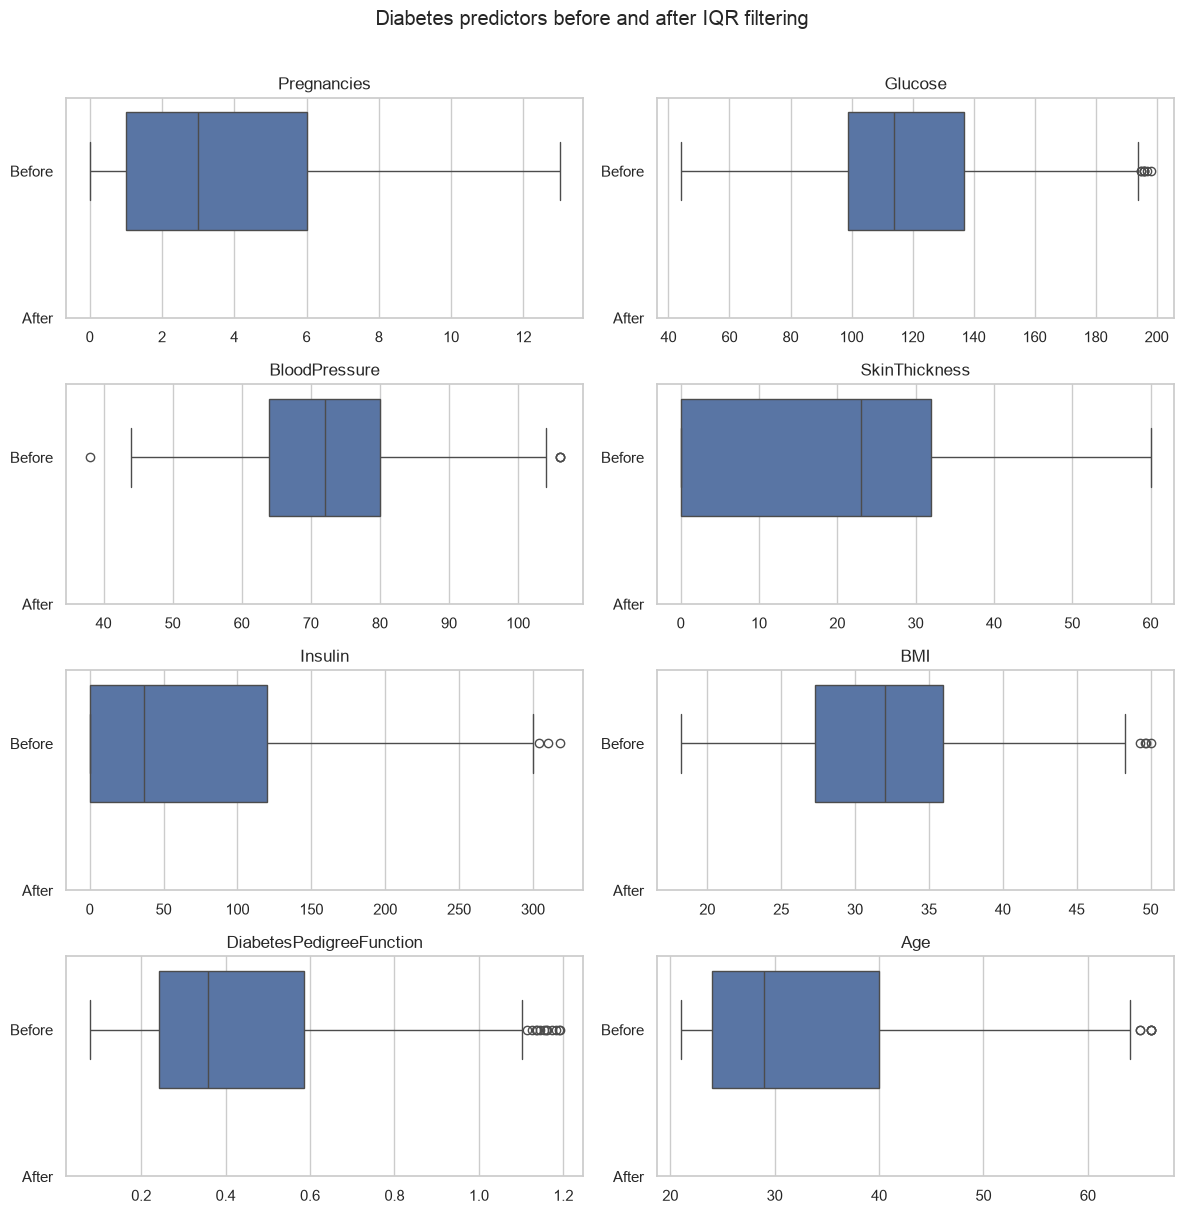

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
for axis, column in zip(axes.flat, diabetes_features):
    sns.boxplot(data=[diabetes[column], diabetes_clean[column]], orient="h", ax=axis)
    axis.set_yticks([0, 1], labels=["Before", "After"])
    axis.set_title(column)
    axis.set_xlabel("")
fig.suptitle("Diabetes predictors before and after IQR filtering", y=1.01)
plt.tight_layout()
plt.show()

In [10]:
outcome_comparison = pd.DataFrame(
    {
        "before_count": diabetes["Outcome"].value_counts().sort_index(),
        "after_count": diabetes_clean["Outcome"].value_counts().sort_index(),
        "before_pct": 100 * diabetes["Outcome"].value_counts(normalize=True).sort_index(),
        "after_pct": 100 * diabetes_clean["Outcome"].value_counts(normalize=True).sort_index(),
    }
)
outcome_comparison.index = outcome_comparison.index.map({0: "No diabetes", 1: "Diabetes"})
outcome_comparison.round(1)

,before_count,after_count,before_pct,after_pct
Outcome,,,,
No diabetes,500,439,65.1,68.7
Diabetes,268,200,34.9,31.3


The positive class falls from 34.9% to 31.3% after filtering. IQR filtering is therefore
not automatically “better” data cleaning: some extreme clinical observations may be valid,
and deleting them can alter the population represented by the dataset.

### 2. Diabetes: compare feature scalers

In [11]:
diabetes_X = diabetes_clean[diabetes_features]

diabetes_minmax = pd.DataFrame(
    MinMaxScaler().fit_transform(diabetes_X),
    columns=diabetes_features,
    index=diabetes_X.index,
)
diabetes_standard = pd.DataFrame(
    StandardScaler().fit_transform(diabetes_X),
    columns=diabetes_features,
    index=diabetes_X.index,
)

pd.concat(
    {
        "original": diabetes_X.head(3),
        "minmax": diabetes_minmax.head(3),
        "standard": diabetes_standard.head(3),
    },
    axis=1,
).round(3)

original                                                    \
  Pregnancies Glucose BloodPressure SkinThickness Insulin   BMI   
0           6     148            72            35       0  33.6   
1           1      85            66            29       0  26.6   
2           8     183            64             0       0  23.3   

                                    minmax          ...  \
  DiabetesPedigreeFunction Age Pregnancies Glucose  ...   
0                    0.627  50       0.462   0.675  ...   
1                    0.351  31       0.077   0.266  ...   
2                    0.672  32       0.615   0.903  ...   

                                     standard                        \
  DiabetesPedigreeFunction    Age Pregnancies Glucose BloodPressure   
0                    0.493  0.644       0.674   0.991        -0.011   
1                    0.245  0.222      -0.861  -1.171        -0.540   
2                    0.534  0.244       1.288   2.192        -0.716   

                                                                
  SkinThickness Insulin    BMI DiabetesPedigreeFunction    Age  
0         0.942  -0.829  0.248                    0.789  1.561  
1         0.550  -0.829 -0.841                   -0.312 -0.155  
2        -1.342  -0.829 -1.354                    0.968 -0.065  

[3 rows x 24 columns]

In [12]:
diabetes_scaling_checks = pd.DataFrame(
    {
        "minmax_min": diabetes_minmax.min(),
        "minmax_max": diabetes_minmax.max(),
        "standard_mean": diabetes_standard.mean(),
        "standard_std_ddof0": diabetes_standard.std(ddof=0),
    }
)
diabetes_scaling_checks.round(6)

,minmax_min,minmax_max,standard_mean,standard_std_ddof0
Pregnancies,0.0,1.0,0.0,1.0
Glucose,0.0,1.0,-0.0,1.0
BloodPressure,0.0,1.0,-0.0,1.0
SkinThickness,0.0,1.0,0.0,1.0
Insulin,0.0,1.0,-0.0,1.0
BMI,0.0,1.0,-0.0,1.0
DiabetesPedigreeFunction,0.0,1.0,-0.0,1.0
Age,0.0,1.0,0.0,1.0


### 3. Employees: outlier detection without unnecessary row deletion

In [13]:
employee_features = ["Salary", "Bonus %"]
employees_clean, employee_iqr_summary, employee_flags = filter_iqr_outliers(
    employees, employee_features
)

employee_results = employee_iqr_summary.assign(
    rows_before=len(employees),
    rows_flagged=int(employee_flags.any(axis=1).sum()),
    rows_after=len(employees_clean),
)
employee_results.round(3)

,lower_bound,upper_bound,flagged_values,rows_before,rows_flagged,rows_after
Salary,-21577.875,202931.125,0,1000,0,1000
Bonus %,-8.753,28.992,0,1000,0,1000


The categorical employee fields contain missing values, but the two features used in this
exercise do not. Dropping every row with any missing categorical field would remove 236
otherwise usable observations. The workflow therefore limits missing-data handling to the
columns required by the analysis.

In [14]:
employee_missing_context = pd.Series(
    {
        "missing_salary": int(employees["Salary"].isna().sum()),
        "missing_bonus": int(employees["Bonus %"].isna().sum()),
        "rows_with_other_missing_fields": int(
            employees.drop(columns=employee_features).isna().any(axis=1).sum()
        ),
    },
    name="rows",
)
employee_missing_context.to_frame()

,rows
missing_salary,0
missing_bonus,0
rows_with_other_missing_fields,236


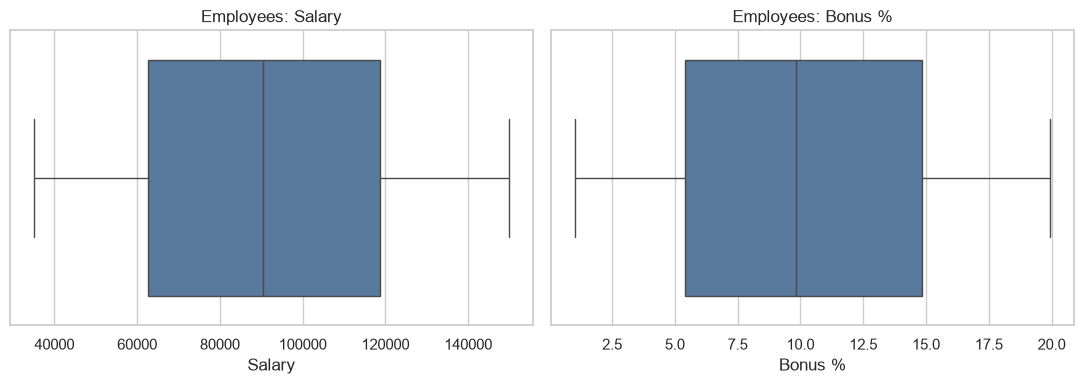

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for axis, column in zip(axes, employee_features):
    sns.boxplot(x=employees_clean[column], ax=axis, color="#4C78A8")
    axis.set_title(f"Employees: {column}")
plt.tight_layout()
plt.show()

In [16]:
employee_X = employees_clean[employee_features]
employee_minmax = pd.DataFrame(
    MinMaxScaler().fit_transform(employee_X),
    columns=employee_features,
    index=employee_X.index,
)
employee_standard = pd.DataFrame(
    StandardScaler().fit_transform(employee_X),
    columns=employee_features,
    index=employee_X.index,
)

employee_scaling_checks = pd.DataFrame(
    {
        "minmax_min": employee_minmax.min(),
        "minmax_max": employee_minmax.max(),
        "standard_mean": employee_standard.mean(),
        "standard_std_ddof0": employee_standard.std(ddof=0),
    }
)
employee_scaling_checks.round(6)

,minmax_min,minmax_max,standard_mean,standard_std_ddof0
Salary,0.0,1.0,0.0,1.0
Bonus %,0.0,1.0,-0.0,1.0


## Checks

In [17]:
assert len(diabetes) == 768
assert len(diabetes_clean) == 639
assert int(diabetes_flags.any(axis=1).sum()) == 129
assert len(employees) == 1000
assert len(employees_clean) == 1000
assert not employee_flags.any(axis=1).any()

assert np.allclose(diabetes_minmax.min().to_numpy(), 0.0)
assert np.allclose(diabetes_minmax.max().to_numpy(), 1.0)
assert np.allclose(diabetes_standard.mean().to_numpy(), 0.0, atol=1e-10)
assert np.allclose(diabetes_standard.std(ddof=0).to_numpy(), 1.0, atol=1e-10)
assert np.allclose(employee_minmax.min().to_numpy(), 0.0)
assert np.allclose(employee_minmax.max().to_numpy(), 1.0)
assert np.allclose(employee_standard.mean().to_numpy(), 0.0, atol=1e-10)
assert np.allclose(employee_standard.std(ddof=0).to_numpy(), 1.0, atol=1e-10)

print("All validation checks passed.")

All validation checks passed.


## Takeaways

- IQR filtering is transparent and reproducible, but it is a statistical rule rather than
  proof that an observation is erroneous.
- The Diabetes filter removes 16.8% of rows and changes the outcome distribution, so domain
  review is essential before using the filtered data for modelling.
- The Employees data demonstrates that a valid method can correctly return zero outliers;
  preprocessing should not force data removal.
- Min–Max scaling and standardisation solve different representation needs. Neither removes
  outliers, and both should be fitted only on training data in a predictive workflow.

### Possible extension

Compare this workflow with `RobustScaler`, which uses robust statistics and may be preferable
when valid extreme observations should be retained.